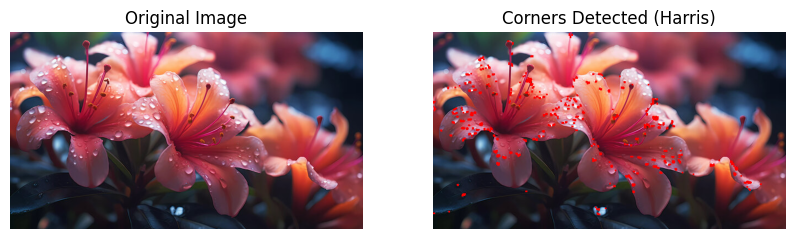

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. Read the image
# Replace 'path/to/your/image.jpg' with the actual path to your image file
image_path = 'Flower.jpg'

# It's recommended to upload an image to your Colab environment or provide a URL.
# For example, you can drag and drop an image into the 'Files' section (folder icon on the left panel)
# and then use its path, e.g., 'your_image_name.jpg'

# --- AUTOMATICALLY DOWNLOAD A SAMPLE IMAGE IF PLACEHOLDER IS USED ---
if image_path == 'path/to/your/image.jpg':
    sample_image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/home.jpg'
    sample_image_name = 'home.jpg'
    print(f"Placeholder path detected. Downloading sample image from {sample_image_url}...")
    try:
        response = requests.get(sample_image_url, stream=True)
        response.raise_for_status() # Raise an exception for bad status codes
        with open(sample_image_name, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        image_path = sample_image_name
        print(f"Sample image saved as {sample_image_name}.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading sample image: {e}")
        print("Please provide a valid image path or ensure an internet connection.")
        image = None # Set image to None to trigger the error handling below
else:
    image = cv2.imread(image_path)

if image is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file exists.")
    # Attempt to load image only if it hasn't been set to None by download error
    if 'image' not in locals() or image is not None: # If image was not set to None due to download, try loading it.
        image = cv2.imread(image_path)
else:
    # Make a copy to draw on
    img_display = image.copy()

    # 2. Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 3. Apply Harris Corner Detection
    # Parameters:
    # blockSize: It is the size of neighbour considered for corner detection
    # ksize: Aperture parameter of Sobel derivative used.
    # k: Harris detector free parameter in the equation
    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # Result is dilated for marking the corners, not important to the science
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image.
    # Mark corners in red
    img_display[dst > 0.01 * dst.max()] = [0, 0, 255] # BGR format for OpenCV

    # 4. Display the original and corner-detected images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    plt.title('Corners Detected (Harris)')
    plt.axis('off')

    plt.show()